In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

df = pd.read_csv("sales_data.csv")

# the data is reshaped so that products become rows and regions become columns
matrix = df.pivot_table(index="Product", columns="Region",
                        values="Sales", aggfunc="sum")

print("Product versus Region matrix:")
print(matrix)
print("\nRegions :", list(matrix.columns))
print("Products :", list(matrix.index))

Product versus Region matrix:
Region     East   North   South    West
Product                                
Laptop   113000  158000   99000  141000
Mobile    86000  124000  108000   77000
Printer   87000   59000   96000   53000

Regions : ['East', 'North', 'South', 'West']
Products : ['Laptop', 'Mobile', 'Printer']


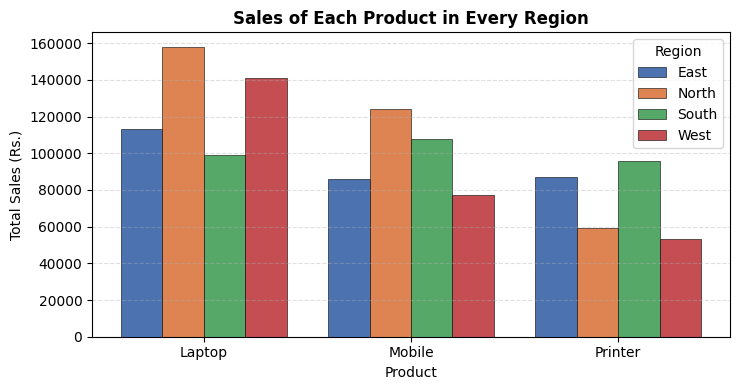

In [2]:
# ---------------- Grouped bar chart ----------------
labels = matrix.index
x = np.arange(len(labels))
width = 0.2
colors = ["#4c72b0", "#dd8452", "#55a868", "#c44e52"]

plt.figure(figsize=(7.5, 4))
for i, region in enumerate(matrix.columns):
    plt.bar(x + i * width, matrix[region], width,
            label=region, color=colors[i], edgecolor="black", linewidth=0.4)

plt.title("Sales of Each Product in Every Region", fontsize=12, fontweight="bold")
plt.xlabel("Product")
plt.ylabel("Total Sales (Rs.)")
plt.xticks(x + width * 1.5, labels)
plt.legend(title="Region")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

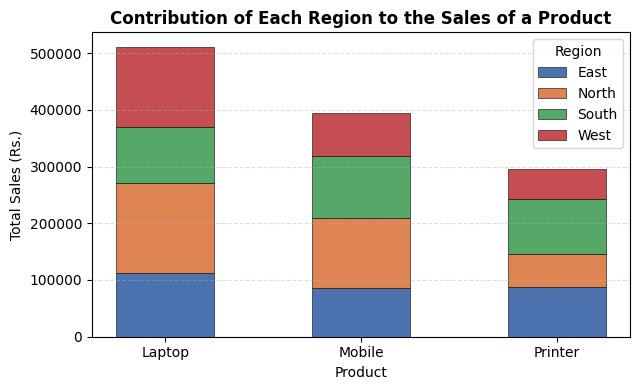

In [3]:
# ---------------- Stacked bar chart ----------------
plt.figure(figsize=(6.5, 4))
bottom = np.zeros(len(matrix))

for i, region in enumerate(matrix.columns):
    plt.bar(matrix.index, matrix[region], 0.5, bottom=bottom,
            label=region, color=colors[i], edgecolor="black", linewidth=0.4)
    bottom += matrix[region].values

plt.title("Contribution of Each Region to the Sales of a Product",
          fontsize=12, fontweight="bold")
plt.xlabel("Product")
plt.ylabel("Total Sales (Rs.)")
plt.legend(title="Region")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

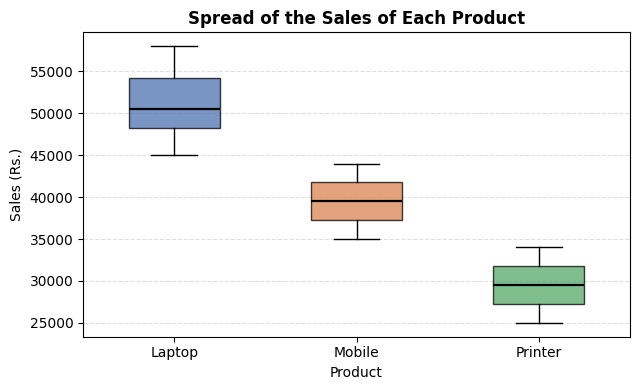

In [4]:
# ---------------- Box plot ----------------
groups = [df[df["Product"] == p]["Sales"].values for p in df["Product"].unique()]

plt.figure(figsize=(6.5, 4))
bp = plt.boxplot(groups, patch_artist=True, widths=0.5,
                 medianprops={"color": "black", "linewidth": 1.6})
plt.xticks(range(1, len(groups) + 1), df["Product"].unique())

for patch, c in zip(bp["boxes"], ["#4c72b0", "#dd8452", "#55a868"]):
    patch.set_facecolor(c)
    patch.set_alpha(0.75)

plt.title("Spread of the Sales of Each Product", fontsize=12, fontweight="bold")
plt.xlabel("Product")
plt.ylabel("Sales (Rs.)")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

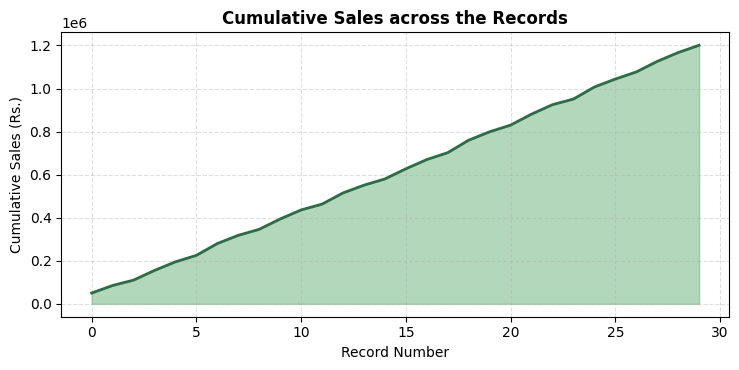

Total cumulative sales : 1201000


In [5]:
# ---------------- Area chart ----------------
cumulative = df["Sales"].cumsum()

plt.figure(figsize=(7.5, 3.8))
plt.fill_between(df.index, cumulative, color="#55a868", alpha=0.45)
plt.plot(df.index, cumulative, color="#2f6b46", linewidth=2)

plt.title("Cumulative Sales across the Records", fontsize=12, fontweight="bold")
plt.xlabel("Record Number")
plt.ylabel("Cumulative Sales (Rs.)")
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

print("Total cumulative sales :", cumulative.iloc[-1])

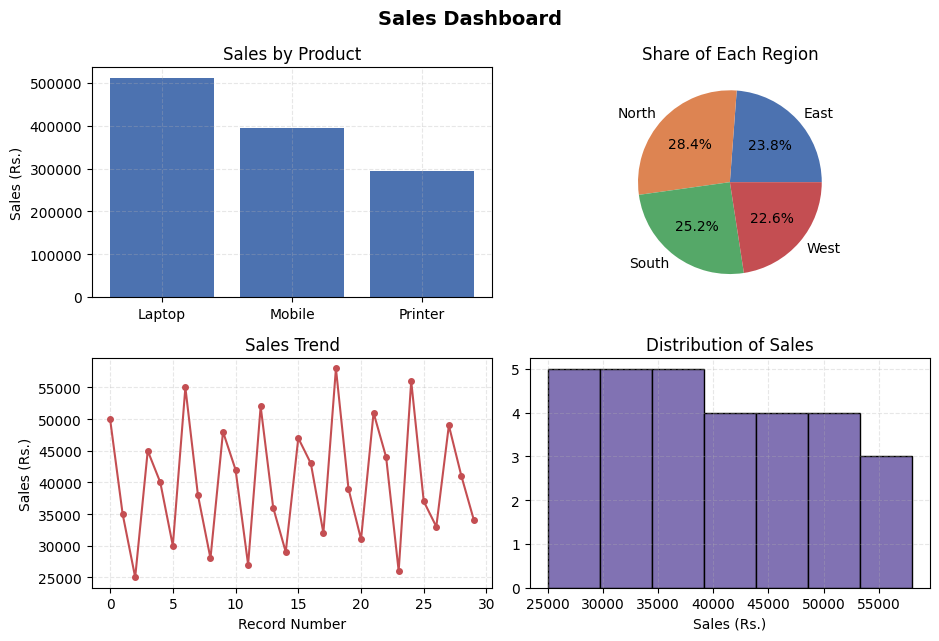

In [6]:
# ---------------- Multiple subplots in a single figure ----------------
product_sales = df.groupby("Product")["Sales"].sum()
region_sales = df.groupby("Region")["Sales"].sum()

fig, axes = plt.subplots(2, 2, figsize=(9.5, 6.5))
fig.suptitle("Sales Dashboard", fontsize=14, fontweight="bold")

axes[0, 0].bar(product_sales.index, product_sales.values, color="#4c72b0")
axes[0, 0].set_title("Sales by Product")
axes[0, 0].set_ylabel("Sales (Rs.)")

axes[0, 1].pie(region_sales.values, labels=region_sales.index,
               autopct="%1.1f%%", colors=colors)
axes[0, 1].set_title("Share of Each Region")

axes[1, 0].plot(df.index, df["Sales"], marker="o", color="#c44e52", markersize=4)
axes[1, 0].set_title("Sales Trend")
axes[1, 0].set_xlabel("Record Number")
axes[1, 0].set_ylabel("Sales (Rs.)")

axes[1, 1].hist(df["Sales"], bins=7, color="#8172b3", edgecolor="black")
axes[1, 1].set_title("Distribution of Sales")
axes[1, 1].set_xlabel("Sales (Rs.)")

for ax in axes.flat:
    ax.grid(alpha=0.3, linestyle="--")

plt.tight_layout()
plt.show()

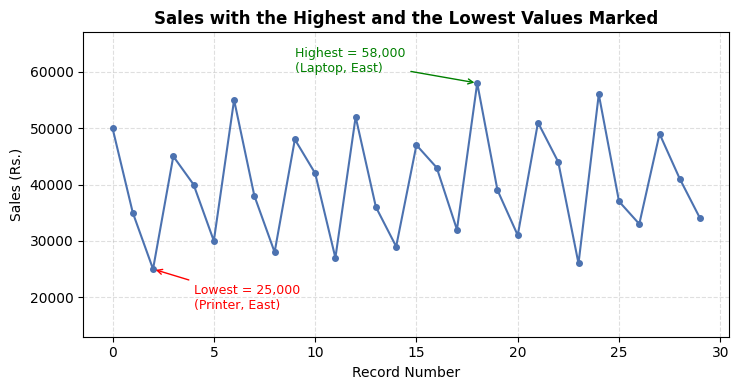

In [7]:
# ---------------- Annotating a plot ----------------
hi = df["Sales"].idxmax()
lo = df["Sales"].idxmin()

plt.figure(figsize=(7.5, 4))
plt.plot(df.index, df["Sales"], marker="o", color="#4c72b0", markersize=4)

plt.annotate(f"Highest = {df.loc[hi, 'Sales']:,}\n({df.loc[hi, 'Product']}, {df.loc[hi, 'Region']})",
             xy=(hi, df.loc[hi, "Sales"]), xytext=(hi - 9, df.loc[hi, "Sales"] + 2000),
             arrowprops={"arrowstyle": "->", "color": "green"},
             fontsize=9, color="green")

plt.annotate(f"Lowest = {df.loc[lo, 'Sales']:,}\n({df.loc[lo, 'Product']}, {df.loc[lo, 'Region']})",
             xy=(lo, df.loc[lo, "Sales"]), xytext=(lo + 2, df.loc[lo, "Sales"] - 7000),
             arrowprops={"arrowstyle": "->", "color": "red"},
             fontsize=9, color="red")

plt.title("Sales with the Highest and the Lowest Values Marked",
          fontsize=12, fontweight="bold")
plt.xlabel("Record Number")
plt.ylabel("Sales (Rs.)")
plt.ylim(df["Sales"].min() - 12000, df["Sales"].max() + 9000)
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

A few of the styles available in Matplotlib:
['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast']


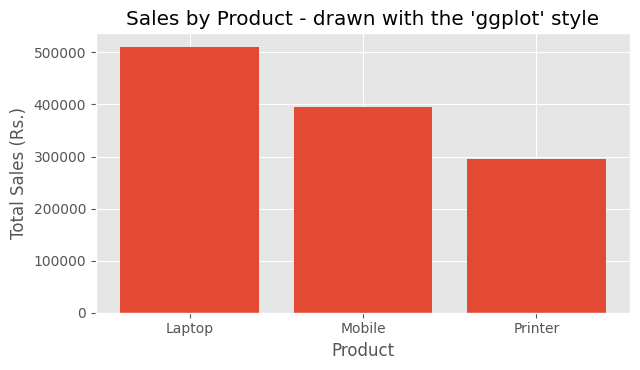

In [8]:
# ---------------- Applying a built-in style sheet ----------------
print("A few of the styles available in Matplotlib:")
print(plt.style.available[:8])

with plt.style.context("ggplot"):
    plt.figure(figsize=(6.5, 3.8))
    plt.bar(product_sales.index, product_sales.values)
    plt.title("Sales by Product - drawn with the 'ggplot' style")
    plt.xlabel("Product")
    plt.ylabel("Total Sales (Rs.)")
    plt.tight_layout()
    plt.show()

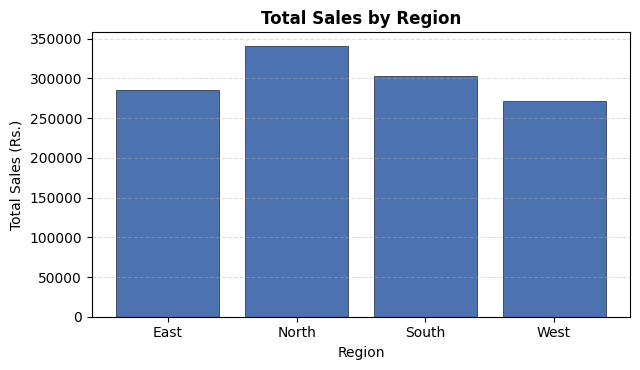

Figure saved as 'sales_by_region.png'
File size : 37392 bytes


In [9]:
# ---------------- Saving the figure as an image file ----------------
fig, ax = plt.subplots(figsize=(6.5, 3.8))
ax.bar(region_sales.index, region_sales.values, color="#4c72b0",
       edgecolor="black", linewidth=0.4)
ax.set_title("Total Sales by Region", fontsize=12, fontweight="bold")
ax.set_xlabel("Region")
ax.set_ylabel("Total Sales (Rs.)")
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()

fig.savefig("sales_by_region.png", dpi=150, bbox_inches="tight")
plt.show()

print("Figure saved as 'sales_by_region.png'")
print("File size :", os.path.getsize("sales_by_region.png"), "bytes")